In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt
import joblib


In [2]:
df=pd.read_csv("kenya_property24_sales_cleaned.csv")
df.head()

,Title,Location,Bedrooms,Bathrooms,House Size,Price,Property Type,Listing Date,Amenities,size_value,size_unit,size_sqft,Price_per_sqft,Amenities_count,Listing Month,Listing Month Name,Listing Year,distance_to_cbd_km
0,3 Bedroom Apartment / Flat,westlands,3.0,4.5,155 m²,24600000,Apartment / Flat,2026-02-20,"400 m fully equipped gym, 17acre shopping mall...",155.0,m²,1668.40,14744.67,11,2,February,2026,5.654415
1,1 Bedroom Apartment / Flat,westlands,1.0,1.0,65 m²,6500000,Apartment / Flat,2026-02-18,none,65.0,m²,699.65,9290.36,1,2,February,2026,5.654415
2,2 Bedroom Apartment / Flat,kilimani,2.0,2.0,110 m²,11800000,Apartment / Flat,2026-02-16,plumeria residency is located at the intersect...,110.0,m²,1184.03,9965.96,12,2,February,2026,4.936608
3,2 Bedroom Apartment / Flat,riverside,2.0,2.0,114 m²,13600000,Apartment / Flat,2026-02-16,"1 bedroom 6081 from ksh 72m to 1092m, 2 bedro...",114.0,m²,1227.08,11083.22,17,2,February,2026,5.982157
4,3 Bedroom Apartment / Flat,westlands,3.0,3.0,155 m²,21714000,Apartment / Flat,2026-02-16,none,155.0,m²,1668.40,13014.86,1,2,February,2026,5.654415


In [3]:
features = ["size_sqft", "Amenities_count", "Bedrooms", "Bathrooms", "Location"]


X = pd.get_dummies(df[features], columns=["Location"], drop_first=True)
y = df["Price"]

- Spliting the dataset

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training shape:", X_train.shape)
print("Columns:", X_train.columns.tolist())

Training shape: (306, 29)
Columns: ['size_sqft', 'Amenities_count', 'Bedrooms', 'Bathrooms', 'Location_donholm', 'Location_embakasi', 'Location_gigiri', 'Location_industrial area', 'Location_karen', 'Location_kasarani', 'Location_kiambu road', 'Location_kileleshwa', 'Location_kilimani', 'Location_kitisuru', 'Location_langata', 'Location_lavington', 'Location_loresho', 'Location_mirema', 'Location_parklands', 'Location_rhapta road', 'Location_riruta', 'Location_riverside', 'Location_runda', 'Location_south c', 'Location_spring valley', 'Location_syokimau', 'Location_upper hill', 'Location_uthiru', 'Location_westlands']


### LinearRegression

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)


mae_lr  = mean_absolute_error(y_test, lr_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_pred))
r2_lr   = r2_score(y_test, lr_pred)

print("\nLinear Regression")
print("MAE:  ", mae_lr)
print("RMSE: ", rmse_lr)
print("R²:   ", r2_lr)


Linear Regression
MAE:   4230467.033349127
RMSE:  6145370.898063043
R²:    0.593344899496889


### Random Forest

In [6]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
r2_rf   = r2_score(y_test, rf_pred)

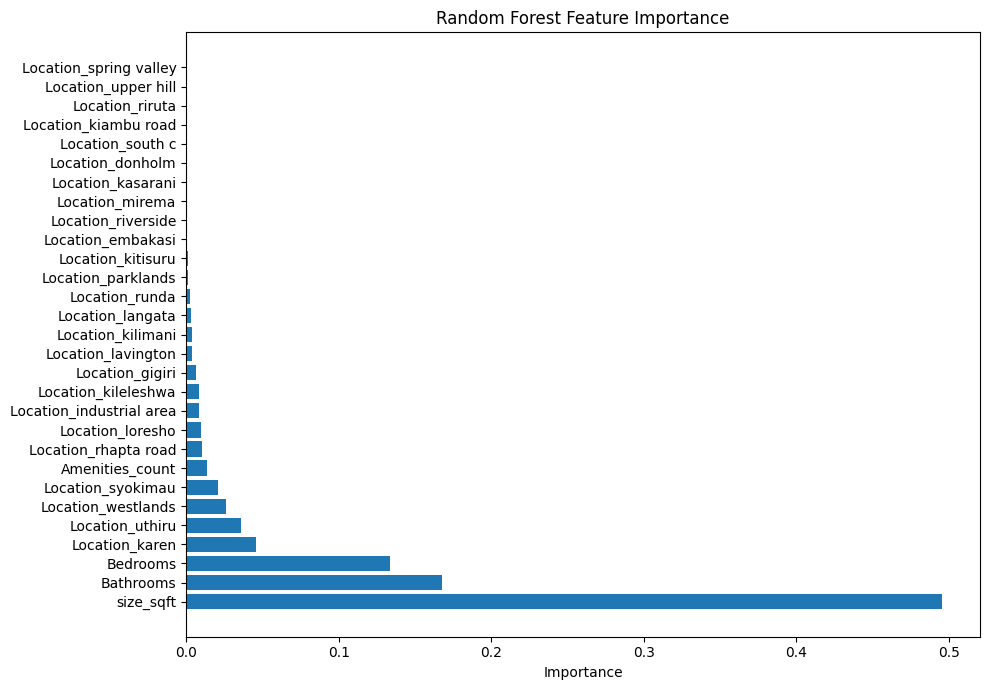

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

ax.barh(range(len(indices)), importances[indices], align='center')
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([X_train.columns[i] for i in indices])
ax.set_xlabel("Importance")
ax.set_title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

### XGBoost

In [8]:
dtrain = xgb.DMatrix(X_train, y_train)
dtest  = xgb.DMatrix(X_test, y_test)

params = {
    'objective': 'reg:squarederror',
    'max_depth': 5,           
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42,
    'tree_method': 'hist',    
}

model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=300,     
    evals=[(dtest, 'validation')],
    early_stopping_rounds=20,
    verbose_eval=50
)

xgb_pred = model.predict(dtest)

mae_xgb  = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
r2_xgb   = r2_score(y_test, xgb_pred)

[0]	validation-rmse:9415587.81087
[50]	validation-rmse:5950172.25464
[100]	validation-rmse:5877666.44724
[150]	validation-rmse:5730810.30474
[200]	validation-rmse:5615028.89493
[250]	validation-rmse:5545993.03466
[299]	validation-rmse:5484150.98748


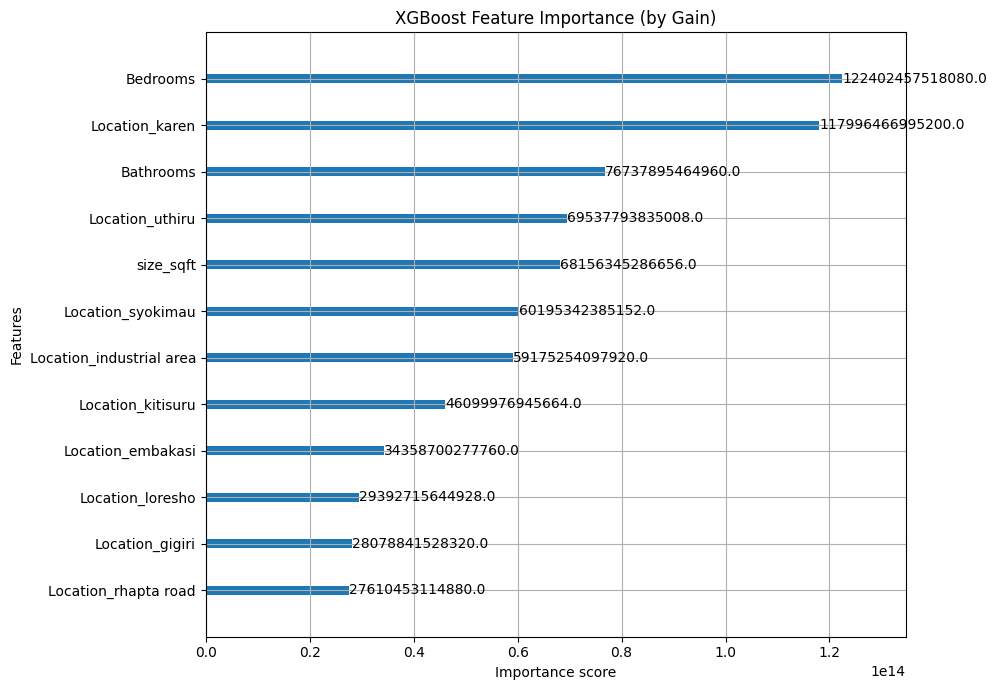

In [9]:

fig, ax = plt.subplots(figsize=(10, 7))
xgb.plot_importance(model, importance_type='gain', max_num_features=12, ax=ax)
ax.set_title("XGBoost Feature Importance (by Gain)")
plt.tight_layout()
plt.show()   # 

In [10]:
joblib.dump({
    'model': model,
    'features': X_train.columns.tolist(),
    'mae': mean_absolute_error(y_test, xgb_pred)   
}, "model.pkl")

print("\nmodel.pkl saved successfully!")


model.pkl saved successfully!


### Comparison of the different models 

In [11]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE (KES)':  [mae_lr,  mae_rf,  mae_xgb],
    'RMSE (KES)': [rmse_lr, rmse_rf, rmse_xgb],
    'R²':         [r2_lr,   r2_rf,   r2_xgb]
}).round(2)

print("Model Comparison Table:")
print(results.to_markdown(index=False))

Model Comparison Table:
| Model             |   MAE (KES) |   RMSE (KES) |   R² |
|:------------------|------------:|-------------:|-----:|
| Linear Regression | 4.23047e+06 |  6.14537e+06 | 0.59 |
| Random Forest     | 2.87252e+06 |  5.82147e+06 | 0.64 |
| XGBoost           | 2.55269e+06 |  5.48415e+06 | 0.68 |
